# Next Steps
- Evaluate other period setups (e.g. agging data to weekly or biweekly and calculating outliers there)
- Evaluate admin-specific appraoch (calc outliers for each admin / time period combo individually)
- Create dict of KP IDs for final dataframe so as to easily link outliers to event descriptions (or some other method but playing dictionaries is fun)
- Evaluate other methods including Arima based band construction and rolling window-based clustering methods / also check out z-scores (or filtering data for last two years and clustering) - covid makes it tough as there is undoubtedly a structural shift. See attempts in master branch of git repository.

In [1]:
#Basic
import pandas as pd
import numpy as np
from pandas.core.reshape.merge import merge_asof
import datetime
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

#Packates
import adtk
from adtk.detector import PersistAD
from adtk.visualization import plot
from sklearn.ensemble import IsolationForest

In [2]:
#### Functions ###
# Convert ACLED Dates to pd
def convert_dt(value):
    valstr = str(value)
    date_clean = datetime(year=int(valstr[0:4]), month=int(valstr[4:6]), day=int(valstr[6:8]))
    return date_clean

# Rolling Window 
def rolling_window(df, window = 30, IQR_x = 1.5):
    persist_ad = PersistAD(window=window, c=IQR_x, side='positive')
    df['rw_anomalies'] = persist_ad.fit_detect(df)
    return df



In [112]:
# Import Data

## Conflict Main
conflict = pd.read_csv('./nigeria_acled.csv')

conflict['ACLED_Year'].value_counts()
len(conflict)

2643

In [7]:
### Data Transformation
## Format Time Series
# Convert int to dtime - inefficient but who cares given small obs size
# Look into python packages available that have better support for time series manipulation
# Pandas (as you can see by this cell) is absolutely terrible

conflict_ts = conflict.copy()
conflict_ts['Date_Clean'] = conflict_ts['TimeFK_Event_Date'].apply(lambda x: convert_dt(x))
conflict_ts[['Date_Clean','TimeFK_Event_Date']]

# Filter by year
conflict_ts = conflict_ts[conflict_ts['Date_Clean'].dt.year >= 2014]

# Aggregate
# Standard
dailydata = conflict_ts.groupby(['Date_Clean']).agg({'Date_Clean':'count'}).rename(columns={'Date_Clean':'Event_Count'})

#Optional dict with kp ids in case we want to link to actor analysis later on
# dailydata = conflict_ts.groupby(['Date_Clean']).agg({'Date_Clean':'count'}).rename(columns={'Date_Clean':'Event_Count'})


# Optional - fill empty dates with zeros
dailydata = dailydata.resample('D').sum().fillna(0)
dailydata


,Event_Count
Date_Clean,
2021-01-01,5
2021-01-02,12
2021-01-03,7
2021-01-04,12
2021-01-05,8
...,...
2021-09-13,10
2021-09-14,15
2021-09-15,5


In [29]:
#### Pulled From biweekly conflict forecasting Script ####
### This just creates a multiindex for daily data
### Data Transformation
## Format Time Series
# Convert int to dtime - inefficient but who cares given small obs size
# Look into python packages available that have better support for time series manipulation
# Pandas (as you can see by this cell) is absolutely terrible
def convert_dt(value):
    valstr = str(value)
    date_clean = datetime(year=int(valstr[0:4]), month=int(valstr[4:6]), day=int(valstr[6:8]))
    return date_clean

conflict_ts = conflict.copy()
conflict_ts['Date_Clean'] = conflict_ts['TimeFK_Event_Date'].apply(lambda x: convert_dt(x))
conflict_ts[['Date_Clean','TimeFK_Event_Date']]

# Filter by year
conflict_ts = conflict_ts[conflict_ts['Date_Clean'].dt.year >= 2019]

# Aggregate
conflict_ts = conflict_ts.groupby(['ACLED_Admin1', 'Date_Clean']).agg({'ACLED_Admin1':'count'})
conflict_ts.rename(columns={'ACLED_Admin1':'Event Count'}, inplace=True)
conflict_ts.reset_index(inplace=True)

# Some vars to make generation of Cartesion Index easy
mindate = min(conflict_ts['Date_Clean'])
maxdate = max(conflict_ts['Date_Clean'])
z = conflict_ts['ACLED_Admin1'].unique()

# Set multi-time index
conflict_ts.set_index(['ACLED_Admin1','Date_Clean'], inplace=True)


# Gen Dataframe with cartesian index
days = pd.date_range(start=mindate,end=maxdate)
new_index = pd.MultiIndex.from_product([z,days])
new_df = conflict_ts.reindex(new_index)

# Check initial results
new_df['Event Count'].sum() # lose 5 events due to 5 admin 2 nas

# Fill missing values with zeros 
# Key assumption: We attach a zero to instances where there is a missing Admin/date combo assuming no conflict event occured (e.g. there is no acled events fo that date/admin).
new_df['Event Count'].fillna(0, inplace=True)
new_df

Event Count
Abia    2021-01-01          0.0
        2021-01-02          0.0
        2021-01-03          0.0
        2021-01-04          0.0
        2021-01-05          0.0
...                         ...
Zamfara 2021-09-13          0.0
        2021-09-14          0.0
        2021-09-15          1.0
        2021-09-16          1.0
        2021-09-17          0.0

[9620 rows x 1 columns]

In [119]:
### Admin Levels ####
# Iterate through sub-dataframes and generate anomalies for each
# Returns concatenated dataframe with original multi-index and anomaly column
dfs = []
for key, series in new_df.groupby(new_df.index.get_level_values(0)):
    series.reset_index(level=0, drop=True, inplace=True)
    z = rolling_window(series) # Anaomaly detection here - see params above
    z['Admin1'] = key
    y = z.set_index([df.index, 'Admin1'])
    dfs.append(y)


In [120]:
pd.concat(dfs)

,,Event Count,rw_anomalies
,Admin1,,
2021-01-01,Abia,0.0,NaN
2021-01-02,Abia,0.0,NaN
2021-01-03,Abia,0.0,NaN
2021-01-04,Abia,0.0,NaN
2021-01-05,Abia,0.0,NaN
...,...,...,...
2021-09-13,Zamfara,0.0,0.0
2021-09-14,Zamfara,0.0,0.0
2021-09-15,Zamfara,1.0,0.0


In [118]:
finaldf = pd.concat(dfs)

print(F"Total event count after data transformation and anomaly detection: {finaldf['Event Count'].sum()}")
print(F"Total number of events in original imported dataframe: {len(conflict)}")

finaldf.to_csv('Webinar_Nigeria_Admin1_Anomalies.csv')


Total event count after data transformation and anomaly detection: 2643.0
Total number of events in original imported dataframe: 2643


In [117]:
finaldf['rw_anomalies'].value_counts()

0.0    7724
1.0     786
Name: rw_anomalies, dtype: int64

In [28]:
### Gen for Admin Specific Anomalies ###

## Create dict of dataframes
di = {}
for i in new_df.index.levels[0]:
    di[i] = new_df.xs(i, level=0)


# df.xs('Aba South', level=0)

{'Aba South':             Event Count
 2021-01-01          0.0
 2021-01-02          0.0
 2021-01-03          0.0
 2021-01-04          0.0
 2021-01-05          0.0
 ...                 ...
 2021-09-13          0.0
 2021-09-14          0.0
 2021-09-15          0.0
 2021-09-16          0.0
 2021-09-17          0.0
 
 [260 rows x 1 columns],
 'Abadan':             Event Count
 2021-01-01          0.0
 2021-01-02          0.0
 2021-01-03          0.0
 2021-01-04          0.0
 2021-01-05          1.0
 ...                 ...
 2021-09-13          0.0
 2021-09-14          0.0
 2021-09-15          0.0
 2021-09-16          0.0
 2021-09-17          0.0
 
 [260 rows x 1 columns],
 'Abaji':             Event Count
 2021-01-01          0.0
 2021-01-02          0.0
 2021-01-03          0.0
 2021-01-04          0.0
 2021-01-05          0.0
 ...                 ...
 2021-09-13          0.0
 2021-09-14          0.0
 2021-09-15          0.0
 2021-09-16          0.0
 2021-09-17          0.0
 
 [260 rows x

In [ ]:
=

0.0    223
1.0      7
Name: rw_anomalies, dtype: int64
[<AxesSubplot:> <AxesSubplot:>]
Event_Count     146.833333
rw_anomalies      0.388889
dtype: float64
0.0    13
1.0     3
2.0     2
Name: rw_anomalies, dtype: int64


,Event_Count,rw_anomalies
Date_Clean,,
2021-01-01,5,NaN
2021-01-02,12,NaN
2021-01-03,7,NaN
2021-01-04,12,NaN
2021-01-05,8,NaN
...,...,...
2021-09-13,10,0.0
2021-09-14,15,0.0
2021-09-15,5,0.0


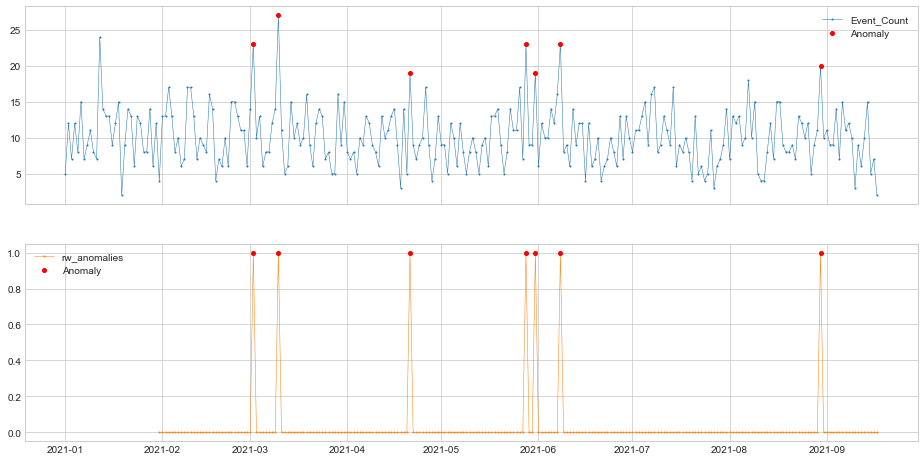

In [41]:
### Old Skool Methods
## Rolling Window
# Params for rolling window
# window = 30 (default) - number of periods to account for
# IQR_x = 1.5 (default - threshold band, increase absolute value for a higher minimum threshold 

# Calculate with default (30 days)
dailydata_iqr = rolling_window(dailydata)

# Calc with 90 days
# dailydata_iqr = rolling_window(dailydata, window = 90)

# # Cal with higher Threshold and 60 days
# dailydata_iqr = rolling_window(dailydata, window = 60, IQR_x=3)

# Examine number of outliers
print(dailydata_iqr['rw_anomalies'].value_counts()) # 188 anaomalies detected


# Plot results
print(plot(dailydata, anomaly=dailydata_iqr['rw_anomalies'], anomaly_color="red", anomaly_tag="marker"))

# Examine biweekly average
biweekly = dailydata.resample('SMS').sum()
# Average number of anomalies per two week period - should also plot the distribution
print(biweekly.mean())
print(biweekly['rw_anomalies'].value_counts())

## 1.093 anomalies per two weeks for a 30 day average - seems reasonable
## average drops to 0.4 if you upgrade threshold to 3
## Examine second graph for observable seasonality

dailydata

[<AxesSubplot:> <AxesSubplot:> <AxesSubplot:>]


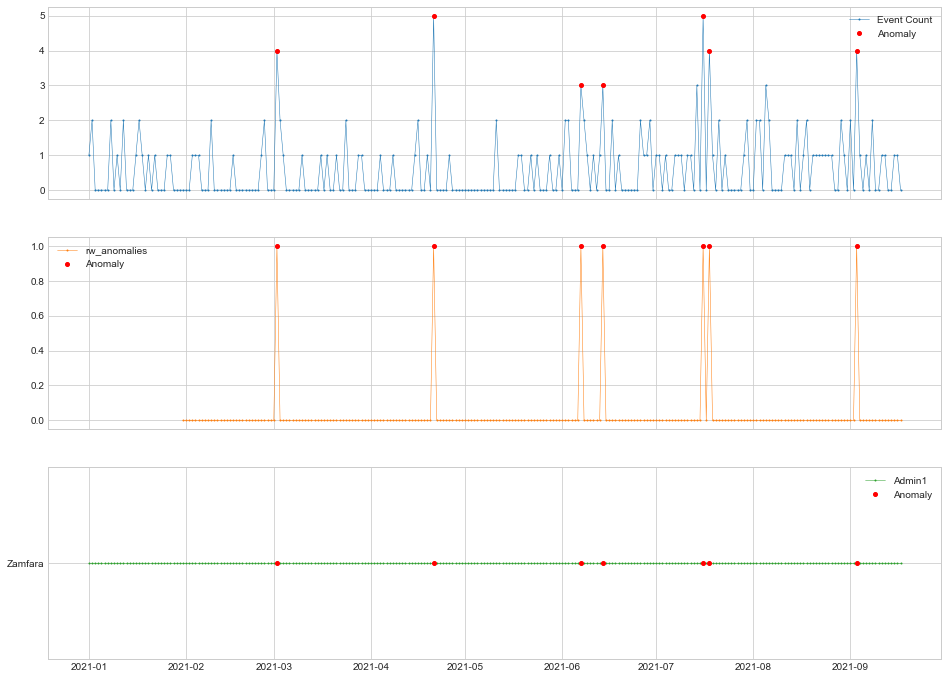

In [109]:
print(plot(z, anomaly=z['rw_anomalies'], anomaly_color="red", anomaly_tag="marker"))


In [6]:
# Check distribution of means via graph here


[<AxesSubplot:>]

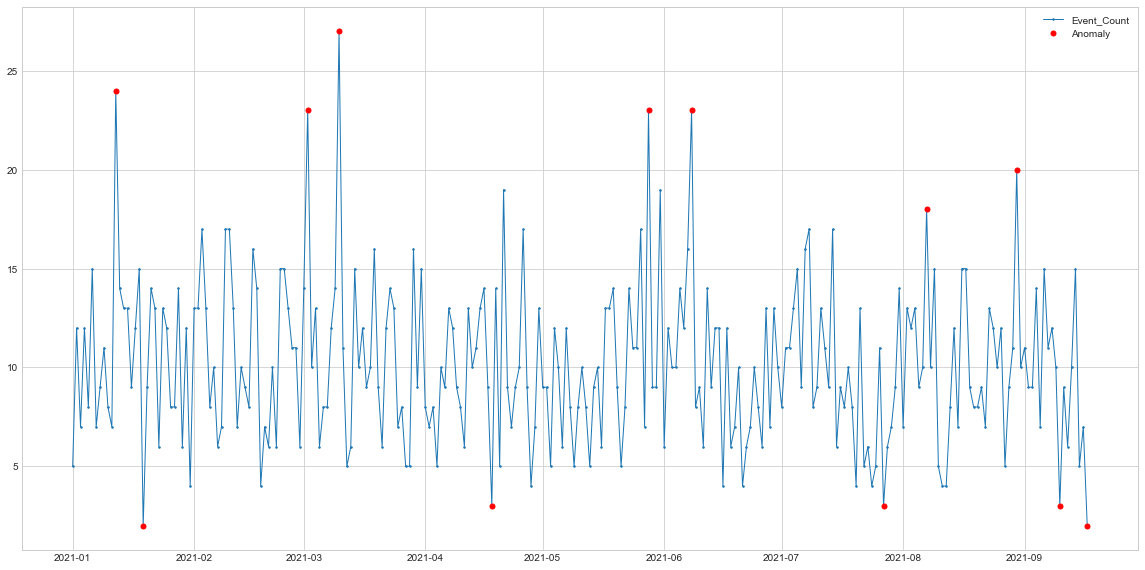

In [9]:
### Tree-Based ###
## Isolation Forest - Global solutions just don't work as well i feel due to the change nature of conflict
## Could try calculating these into rolling windows but then both clustering and efficiency becomes problamatic
IForest = IsolationForest(contamination=0.05)
dailydata_if = IForest.fit_predict(np.array(dailydata.Event_Count).reshape(-1,1))
dailydata_if = pd.Series([x == -1 for x in dailydata_if], index=dailydata.index)
plot(dailydata.Event_Count, anomaly=dailydata_if, ts_linewidth=1, ts_markersize=3, anomaly_color='red', figsize=(20,10), anomaly_tag="marker", anomaly_markersize=5)